In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

In [2]:
def make_W(N, J, rng, kind="gaussian", p=None):
    if kind == "gaussian":
        return rng.normal(0.0, J / np.sqrt(N), size=(N, N))

    if kind == "erdos_renyi":
        if p is None:
            raise ValueError("need p")
        k = max(int(p * N), 1)
        return ((rng.random((N, N)) < p) * (J / k)).astype(float)

    raise ValueError("kind must be 'gaussian' or 'erdos_renyi'")

In [3]:
def init_r(N, kind="uniform", scale=1.0, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    if kind == "uniform":
        return rng.uniform(-scale, scale, size=N)
    if kind == "gaussian":
        return rng.normal(0.0, scale, size=N)
    if kind == "zeros":
        return np.zeros(N)
    if kind == "ones":
        return np.ones(N)

    raise ValueError("kind must be 'uniform', 'gaussian', 'zeros', or 'ones'")

In [4]:
def run_reservoir(W, t=100.0, eps=1e-2, M=200, rng=None,
                  init="uniform", init_scale=1.0):
    N = W.shape[0]
    steps = int(t / eps)

    r = init_r(N, kind=init, scale=init_scale, rng=rng)

    take = np.linspace(0, steps - 1, M, dtype=int)
    out = np.empty((M, N))
    times = np.linspace(0.0, t, M)

    j = 0
    for i in range(steps):
        r += eps * (-r + np.tanh(W @ r))

        if i == take[j]:
            out[j] = r
            j += 1
            if j == M:
                break

    return times, out

In [5]:
def plot_activation_histogram(times, samples, bins=100, vmin=-1.5, vmax=1.5, title=None):
    bin_edges = np.linspace(vmin, vmax, bins + 1)
    H = np.zeros((bins, len(times)))

    for i in range(len(times)):
        counts, _ = np.histogram(samples[i], bins=bin_edges)
        H[:, i] = counts

    plt.figure(figsize=(8, 5))
    im = plt.imshow(
        H,
        aspect="auto",
        origin="lower",
        extent=[times[0], times[-1], vmin, vmax],
        cmap="viridis"
    )
    cbar = plt.colorbar(im)
    cbar.set_label("count")
    plt.xlabel("time")
    plt.ylabel("activation")
    plt.title(title if title is not None else "Activation histogram over time")
    plt.tight_layout()
    plt.show()


def plot_trajectories(times, samples, n_show=25, title=None):
    plt.figure(figsize=(8, 5))
    idx = np.linspace(0, samples.shape[1] - 1, min(n_show, samples.shape[1]), dtype=int)

    for i in idx:
        plt.plot(times, samples[:, i], linewidth=1.2, alpha=0.85)

    plt.xlabel("time")
    plt.ylabel("activation")
    plt.title(title if title is not None else f"{len(idx)} sampled neurons")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

In [6]:
N = 1500
J = 2
t = 1000.0
eps = 1e-2
M = 200
seed = 42

rng = np.random.default_rng(seed)

In [7]:
W_gauss = make_W(N, J, rng, kind="gaussian")
times_g, samples_g = run_reservoir(
    W_gauss,
    t=t,
    eps=eps,
    M=M,
    rng=rng,
    init="uniform",
    init_scale=1.0
)

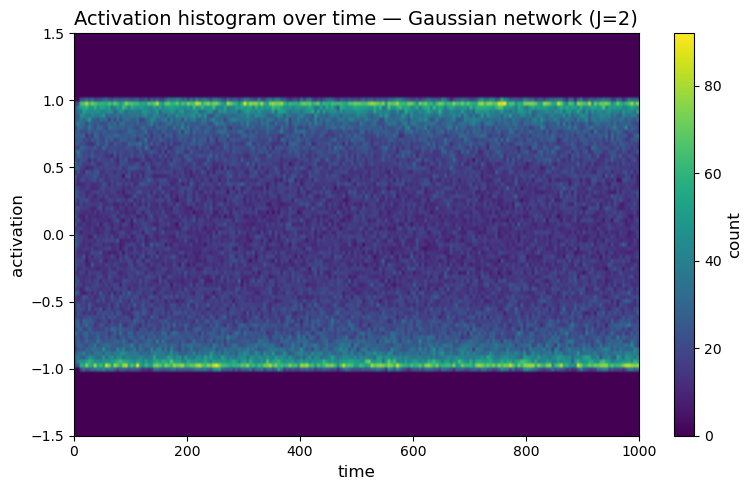

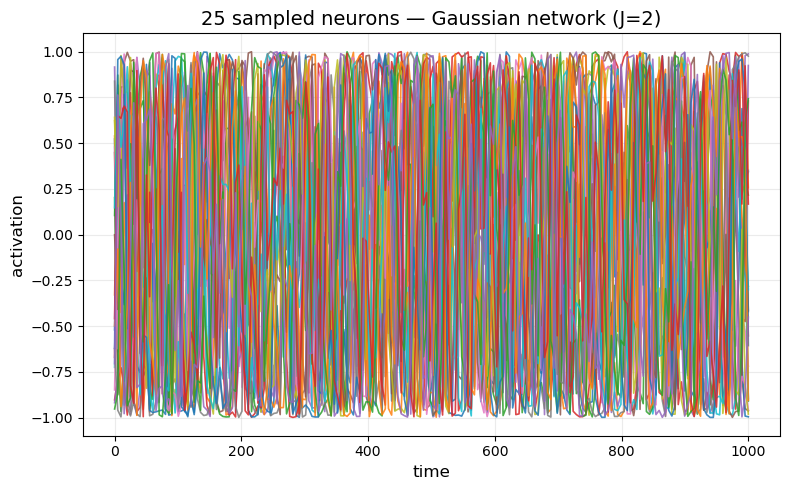

In [8]:
plot_activation_histogram(
    times_g,
    samples_g,
    bins=100,
    vmin=-1.5,
    vmax=1.5,
    title=f"Activation histogram over time — Gaussian network (J={J})"
)

plot_trajectories(
    times_g,
    samples_g,
    n_show=25,
    title=f"25 sampled neurons — Gaussian network (J={J})"
)

In [9]:
p = 0.1

W_er = make_W(N, J, rng, kind="erdos_renyi", p=p)
times_er, samples_er = run_reservoir(
    W_er,
    t=t,
    eps=eps,
    M=M,
    rng=rng,
    init="uniform",
    init_scale=1.0
)

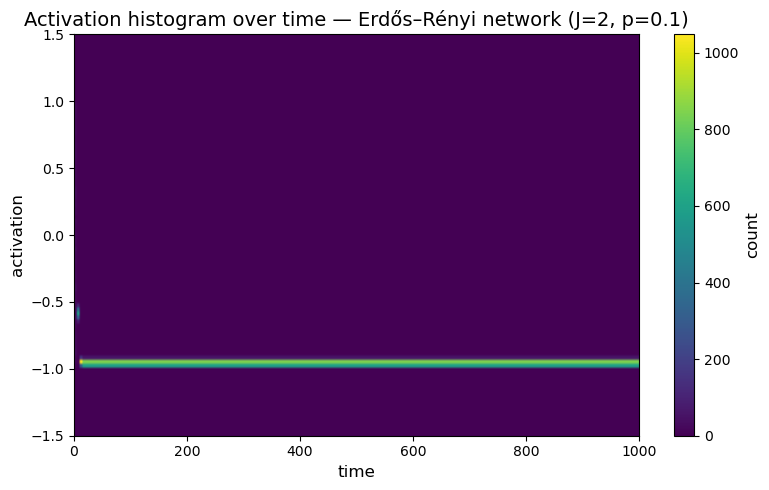

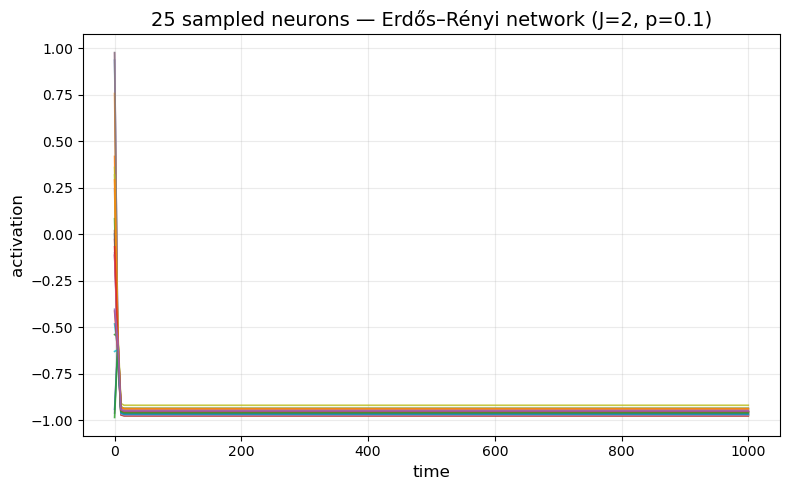

In [10]:
plot_activation_histogram(
    times_er,
    samples_er,
    bins=100,
    vmin=-1.5,
    vmax=1.5,
    title=f"Activation histogram over time — Erdős–Rényi network (J={J}, p={p})"
)

plot_trajectories(
    times_er,
    samples_er,
    n_show=25,
    title=f"25 sampled neurons — Erdős–Rényi network (J={J}, p={p})"
)

### Observation

In the Gaussian case with \( J > 1 \), the activation histogram stays broad over time instead of collapsing toward zero. This indicates that the reservoir does not converge to a fixed point, but maintains persistent fluctuations. The sampled neuron trajectories confirm this behavior, showing irregular oscillations across time, which is consistent with the onset of chaotic dynamics.

In the Erdős–Rényi case, the behavior is qualitatively similar, but the plots may appear slightly less smooth because the connectivity is sparse.



For the Gaussian network with \( J = 2 \), the activation histogram remains broad over time, indicating that neuron activities do not converge to a fixed point. Instead, they continuously fluctuate across a wide range of values. The trajectory plot confirms this behavior: individual neurons exhibit irregular, persistent oscillations, which is characteristic of the chaotic regime (\( J > 1 \)).

In contrast, for the Erdős–Rényi network with the same \( J \), the system quickly collapses to a stable state where most neuron activations concentrate near a constant value (around \(-1\)). This is visible in both the histogram, which becomes sharply concentrated, and the trajectories, where all neurons rapidly converge and remain flat. This suggests that sparsity in the connectivity suppresses chaotic dynamics and leads to a stable fixed point.


In the Gaussian network (\( J = 2 \)), the activity remains broadly distributed over time and neuron trajectories show persistent irregular oscillations, indicating chaotic dynamics.

In the Erdős–Rényi network, activity quickly concentrates near a fixed value and trajectories flatten, showing convergence to a stable fixed point. This highlights how sparse connectivity reduces chaotic behavior.